# Telecom Customer Cancellation & Retention Analysis
This notebook performs exploratory data analysis on the Telecom Customer Churn dataset (Q2 2022) to evaluate key metrics, customer demographics, and drivers of churn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot styling
sns.set_theme(style="whitegrid")
%matplotlib inline

In [2]:
# Load dataset from the data folder
# Note: Ensure the path points correctly to your data folder relative to the notebook location
file_path = '../data/C1_Capstone_Customer_cancellation_analysis.xlsx'
df = pd.read_excel(file_path, sheet_name='Data')

# Display dataset size and column information
print(f"Total Rows: {len(df)}")
df.info()

Total Rows: 7043
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 36 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   str    
 1   Gender                             7043 non-null   str    
 2   Age                                7043 non-null   int64  
 3   Married                            7043 non-null   str    
 4   Number of Dependents               7043 non-null   int64  
 5   City                               7043 non-null   str    
 6   Number of Referrals                7043 non-null   int64  
 7   Tenure in Months                   7043 non-null   int64  
 8   Offer                              3166 non-null   str    
 9   Phone Service                      7043 non-null   str    
 10  Avg Monthly Long Distance Charges  6361 non-null   float64
 11  Multiple Lines                     6361 non-null  

## 1. Key Metrics & Churn Rate Analysis
Calculating general churn proportions, contract duration distribution, and offer effectiveness.

In [4]:
# 1. Overall Churn Rate
total_customers = len(df)
churned_customers = (df['Customer Status'] == 'Churned').sum()
churn_rate = (churned_customers / total_customers) * 100

print(f"Overall Churn Rate: {churn_rate:.2f}%\n")

# 2. Churn by Contract Type
churn_by_contract = df[df['Customer Status'] == 'Churned']['Contract'].value_counts()
print("Churn by Contract Type:")
print(churn_by_contract)
print("\n" + "-"*40 + "\n")

# 3. Churn Rate by Offer Type
df['Offer_Filled'] = df['Offer'].fillna('None')
offer_churn_rate = df.groupby('Offer_Filled')['Customer Status'].apply(lambda x: (x == 'Churned').mean() * 100)
print("Churn Rate (%) by Offer Type:")
print(offer_churn_rate.sort_values(ascending=False))

Overall Churn Rate: 26.54%

Churn by Contract Type:
Contract
Month-to-Month    1655
One Year           166
Two Year            48
Name: count, dtype: int64

----------------------------------------

Churn Rate (%) by Offer Type:
Offer_Filled
Offer E    52.919255
None       27.108589
Offer D    26.744186
Offer C    22.891566
Offer B    12.257282
Offer A     6.730769
Name: Customer Status, dtype: float64


## 2. Visualizing Churn Behavior
Visualizing churn distribution across tenure and contract type.

C:\Users\AVIRAJ\AppData\Local\Temp\ipykernel_32444\3528987563.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=contract_data.index, y=contract_data.values, palette="Blues_r")


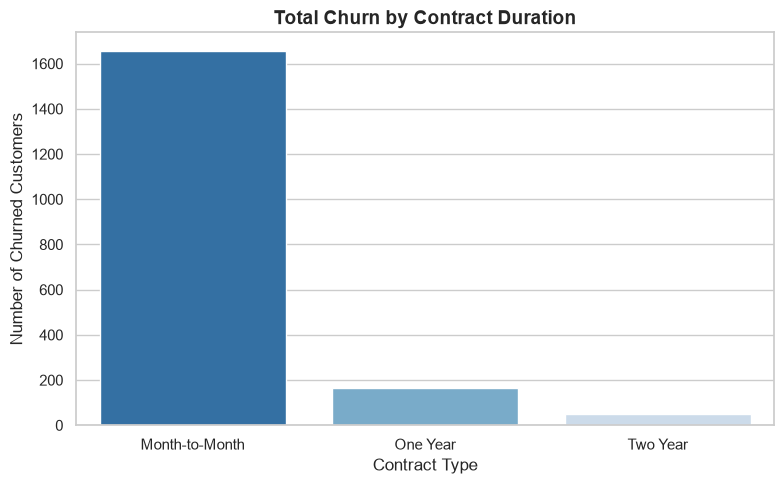

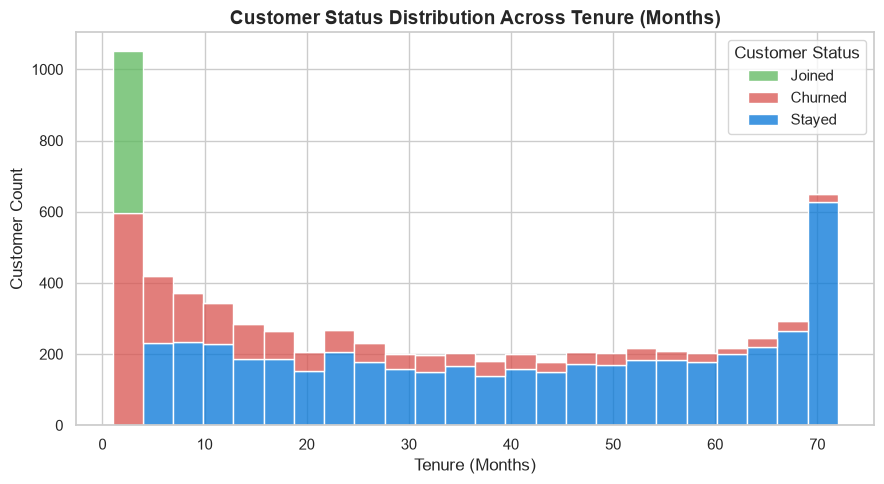

In [5]:
# Chart 1: Churn by Contract Duration
plt.figure(figsize=(8, 5))
contract_data = df[df['Customer Status'] == 'Churned']['Contract'].value_counts()
sns.barplot(x=contract_data.index, y=contract_data.values, palette="Blues_r")
plt.title("Total Churn by Contract Duration", fontsize=14, fontweight='bold')
plt.xlabel("Contract Type", fontsize=12)
plt.ylabel("Number of Churned Customers", fontsize=12)
plt.tight_layout()
plt.savefig("../visuals/churn_by_contract.png")
plt.show()

# Chart 2: Customer Tenure vs. Status
plt.figure(figsize=(9, 5))
sns.histplot(
    data=df, 
    x="Tenure in Months", 
    hue="Customer Status", 
    multiple="stack", 
    bins=24, 
    palette={"Churned": "#d9534f", "Stayed": "#0275d8", "Joined": "#5cb85c"}
)
plt.title("Customer Status Distribution Across Tenure (Months)", fontsize=14, fontweight='bold')
plt.xlabel("Tenure (Months)", fontsize=12)
plt.ylabel("Customer Count", fontsize=12)
plt.tight_layout()
plt.savefig("../visuals/tenure_vs_churn.png")
plt.show()

## 3. Churn Reason Analysis
Identifying primary causes behind customer attrition.

C:\Users\AVIRAJ\AppData\Local\Temp\ipykernel_32444\3431319833.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=reasons_data.values, y=reasons_data.index, palette="Reds_r")


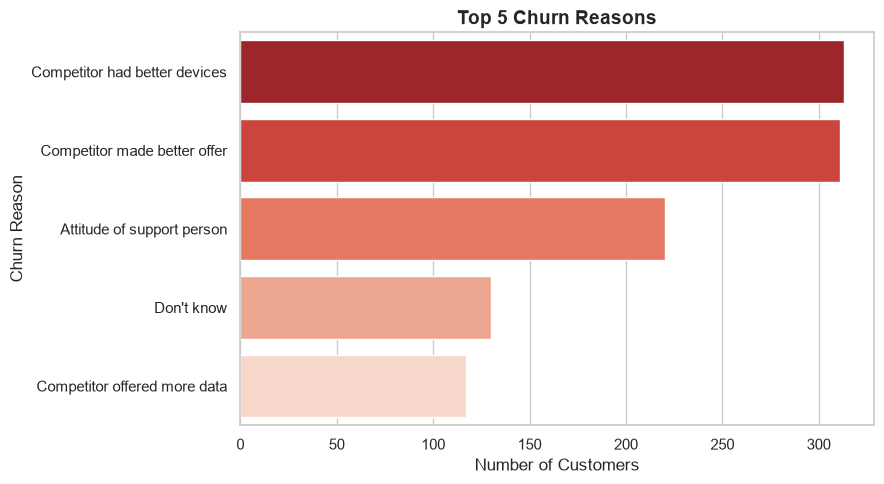

In [6]:
# Chart 3: Top Churn Reasons
plt.figure(figsize=(9, 5))
reasons_data = df['Churn Reason'].value_counts().head(5)
sns.barplot(x=reasons_data.values, y=reasons_data.index, palette="Reds_r")
plt.title("Top 5 Churn Reasons", fontsize=14, fontweight='bold')
plt.xlabel("Number of Customers", fontsize=12)
plt.ylabel("Churn Reason", fontsize=12)
plt.tight_layout()
plt.savefig("../visuals/churn_reasons.png")
plt.show()